#synthetic data with different scale and texture

C:\Users\hosse\AppData\Local\Temp\ipykernel_39012\31110306.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Inter-rater error bar chart with broken axis (SCALES) saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\inter_rater_euclidean_distance_error_bar_broken_axis_SCALES.png


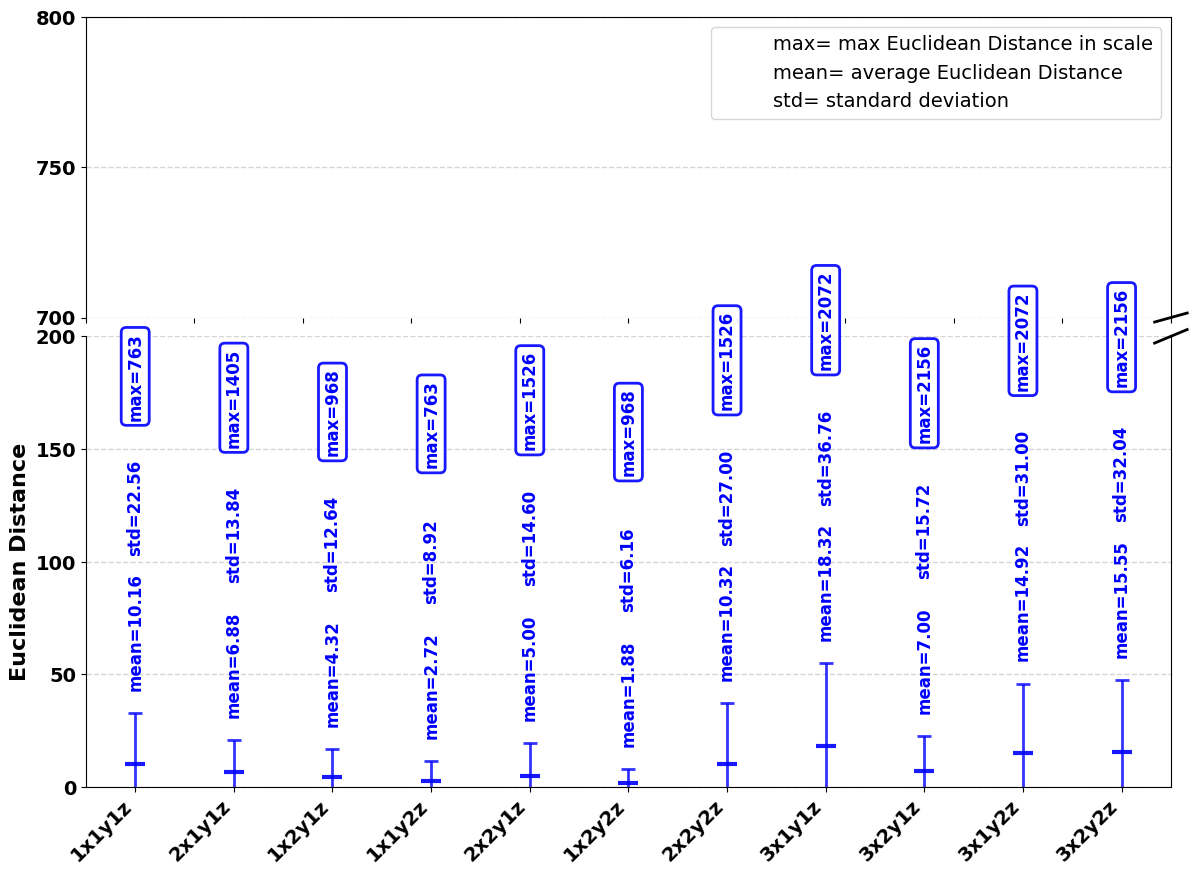


DATA SUMMARY - SCALES
 Type   Name  Mean Euclidean Distance  Std Euclidean Distance       Max_Y  Display_Max
Scale 1x1y1z                    2.540                    5.64  761.000000   763.047181
Scale 2x1y1z                    1.720                    3.46 1401.052698  1404.821697
Scale 1x2y1z                    1.080                    3.16  965.518851   968.116212
Scale 1x1y2z                    0.680                    2.23  761.282264   763.330204
Scale 2x2y1z                    1.250                    3.65 1521.858835  1525.952817
Scale 1x2y2z                    0.470                    1.54  965.741341   968.339300
Scale 2x2y2z                    2.580                    6.75 1522.000000  1526.094361
Scale 3x1y1z                    4.580                    9.19 2066.235248  2071.793667
Scale 3x2y1z                    1.750                    3.93 2149.984594  2155.768309
Scale 3x1y2z                    3.730                    7.75 2066.339223  2071.897922
Scale 3x2y2z        

In [7]:
"""
Inter-Rater Error Bar Chart with Broken Y-Axis - SCALES ONLY
Creates error bar chart with broken y-axis for Scales only
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'
DISTANCE_MULTIPLIER = 4  # Multiply Y-axis by 64

# Original dimensions
ORIGINAL_X = 681
ORIGINAL_Y = 344
ORIGINAL_Z = 12

# Base maximum for 1x1y1z
BASE_MAX = 761

# Function to parse scale name and extract scale factors
def parse_scale_name(name):
    """Extract scale factors from name like '2x1y1z' or '1x1y1z(RS)'"""
    import re
    # Remove (RS) or (GT) suffix if present
    name_clean = re.sub(r'\([^)]+\)', '', name).strip()
    # Extract numbers before x, y, z
    match = re.match(r'(\d+)x(\d+)y(\d+)z', name_clean)
    if match:
        return int(match.group(1)), int(match.group(2)), int(match.group(3))
    return 1, 1, 1  # Default to 1x1y1z if parsing fails

# Function to calculate maximum Y for a given scale
def calculate_max_y(scale_x, scale_y, scale_z):
    """Calculate maximum Y based on scale factors"""
    # Calculate Euclidean distance for scaled dimensions
    scaled_dist = np.sqrt((scale_x * ORIGINAL_X)**2 + (scale_y * ORIGINAL_Y)**2 + (scale_z * ORIGINAL_Z)**2)
    # Calculate Euclidean distance for base (1x1y1z)
    base_dist = np.sqrt((1 * ORIGINAL_X)**2 + (1 * ORIGINAL_Y)**2 + (1 * ORIGINAL_Z)**2)
    # Scale the maximum proportionally
    max_y = BASE_MAX * (scaled_dist / base_dist)
    return max_y

# Function to calculate maximum value for display (Euclidean distance)
def calculate_display_max(scale_x, scale_y, scale_z):
    """Calculate maximum value for display using Euclidean distance"""
    # Calculate Euclidean distance for scaled dimensions
    max_distance = np.sqrt((scale_x * ORIGINAL_X)**2 + (scale_y * ORIGINAL_Y)**2 + (scale_z * ORIGINAL_Z)**2)
    return max_distance

# Data from the results
data = {
    'Type': ['Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale'],
    'Name': ['1x1y1z', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z','3x1y1z', '3x2y1z', '3x1y2z', '3x2y2z'],
    
    'Mean Euclidean Distance': [2.54, 1.72, 1.08, 0.68, 1.25, 0.47, 2.58, 4.58, 1.75, 3.73, 3.887],
    'Std Euclidean Distance': [5.64, 3.46, 3.16, 2.23, 3.65, 1.54, 6.75, 9.19, 3.93, 7.75, 8.01]
}

df = pd.DataFrame(data)

# Separate scales and textures
scale_data = df[df['Type'] == 'Scale'].copy()

# Calculate maximum Y for each scale
scale_data['Max_Y'] = scale_data['Name'].apply(
    lambda name: calculate_max_y(*parse_scale_name(name))
)

# Calculate display maximum for each scale (for labeling)
scale_data['Display_Max'] = scale_data['Name'].apply(
    lambda name: calculate_display_max(*parse_scale_name(name))
)

# Create figure with broken y-axis (crop 300-600)
# Note: High values (600-800) at top, low values (0-300) at bottom
# Top part is 2/3 of bottom part height, same scale step
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.05)  # Top is 2/3 of bottom

# Top subplot (600 to 800) - displayed at top (high values)
ax2 = fig.add_subplot(gs[0, 0])
# Bottom subplot (0 to 300) - displayed at bottom (low values)
ax1 = fig.add_subplot(gs[1, 0])

# Y-axis break parameters
Y_BOTTOM_MAX = 200
Y_TOP_MIN = 700
Y_TOP_MAX = 800

# Calculate x positions for scales only
x_pos_scale = np.arange(len(scale_data))

# Plot scales on both axes
scale_text_positions_bottom = []
scale_text_positions_top = []
if len(scale_data) > 0:
    scale_names = scale_data['Name'].tolist()
    scale_means = (scale_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_stds = (scale_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_display_maxes = scale_data['Display_Max'].tolist()
    scale_colors = ['blue' if name == '1x1y1z(RS)' else 'blue' for name in scale_names]
    
    for i, (mean, std, color, name, display_max) in enumerate(zip(scale_means, scale_stds, scale_colors, scale_names, scale_display_maxes)):
        # Plot on bottom if value <= 300
        if mean <= Y_BOTTOM_MAX:
            ax1.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax1.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_bottom.append((x_pos_scale[i], mean, std, color, mean, display_max))
        # Plot on top if value >= 600
        elif mean >= Y_TOP_MIN:
            ax2.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax2.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_top.append((x_pos_scale[i], mean, std, color, mean, display_max))

# Use scale names and positions only
all_names = scale_data['Name'].tolist()
all_x_pos = list(x_pos_scale)

# Configure top subplot (600-800) - displayed at top (high values)
ax2.set_xticks(all_x_pos)
ax2.set_xticklabels([])  # Hide x labels on top subplot
ax2.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax2.set_ylim(bottom=Y_TOP_MIN, top=Y_TOP_MAX)
ax2.spines['bottom'].set_visible(False)  # Hide bottom spine (broken axis)

# Set same scale step for both subplots (50 units per step)
tick_step = 50
ax2.set_yticks(np.arange(Y_TOP_MIN, Y_TOP_MAX + tick_step, tick_step))

# Configure bottom subplot (0-300) - displayed at bottom (low values)
ax1.set_ylabel(f'Euclidean Distance', fontsize=16, fontweight='bold')
ax1.set_xticks(all_x_pos)
ax1.set_xticklabels(all_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax1.set_ylim(bottom=0, top=Y_BOTTOM_MAX)
ax1.spines['top'].set_visible(False)  # Hide top spine (broken axis)

# Set same scale step for both subplots (50 units per step)
ax1.set_yticks(np.arange(0, Y_BOTTOM_MAX + tick_step, tick_step))

# Add broken axis indicators (diagonal lines)
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=2)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  # Bottom-right diagonal (at bottom of top subplot)

kwargs.update(transform=ax1.transAxes)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # Top-right diagonal (at top of bottom subplot)

# Add mean and std text vertically on top of each bar for SCALES (bottom subplot - 0-300, low values)
for i, (x_pos, mean, std, color, _, display_max) in enumerate(scale_text_positions_bottom):
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean + std + offset
    text_spacing = Y_BOTTOM_MAX * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax1.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax1.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    # Add maximum value with box on top
    max_text_y = text_y_base + text_spacing * 2
    ax1.text(x_pos, max_text_y, f'max={display_max:.0f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color, linewidth=2))

# Add mean and std text vertically on top of each bar for SCALES (top subplot - 600-800, high values)
for i, (x_pos, mean, std, color, _, display_max) in enumerate(scale_text_positions_top):
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean + std + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax2.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax2.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    # Add maximum value with box on top
    max_text_y = text_y_base + text_spacing * 2
    ax2.text(x_pos, max_text_y, f'max={display_max:.0f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color, linewidth=2))

# Add legend (on top subplot - ax2, high values)
legend_elements = [
    plt.Line2D([0], [0], color='white', linewidth=0, marker='', markersize=0, label='max= max Euclidean Distance in scale'),
    plt.Line2D([0], [0], color='white', linewidth=0, marker='', markersize=0, label='mean= average Euclidean Distance'),
        plt.Line2D([0], [0], color='white', linewidth=0, marker='', markersize=0, label='std= standard deviation')

]
ax2.legend(handles=legend_elements, fontsize=14, loc='upper right')
plt.setp(ax1.get_yticklabels(), fontsize=14, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_error_bar_broken_axis_SCALES.png')
plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
print(f"✓ Inter-rater error bar chart with broken axis (SCALES) saved to: {interrater_path}")
plt.show()

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY - SCALES")
print("="*70)
print(scale_data.to_string(index=False))
print("="*70)


C:\Users\hosse\AppData\Local\Temp\ipykernel_36288\1125168719.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Inter-rater error bar chart with broken axis (TEXTURES) saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\inter_rater_euclidean_distance_error_bar_broken_axis_TEXTURES.png


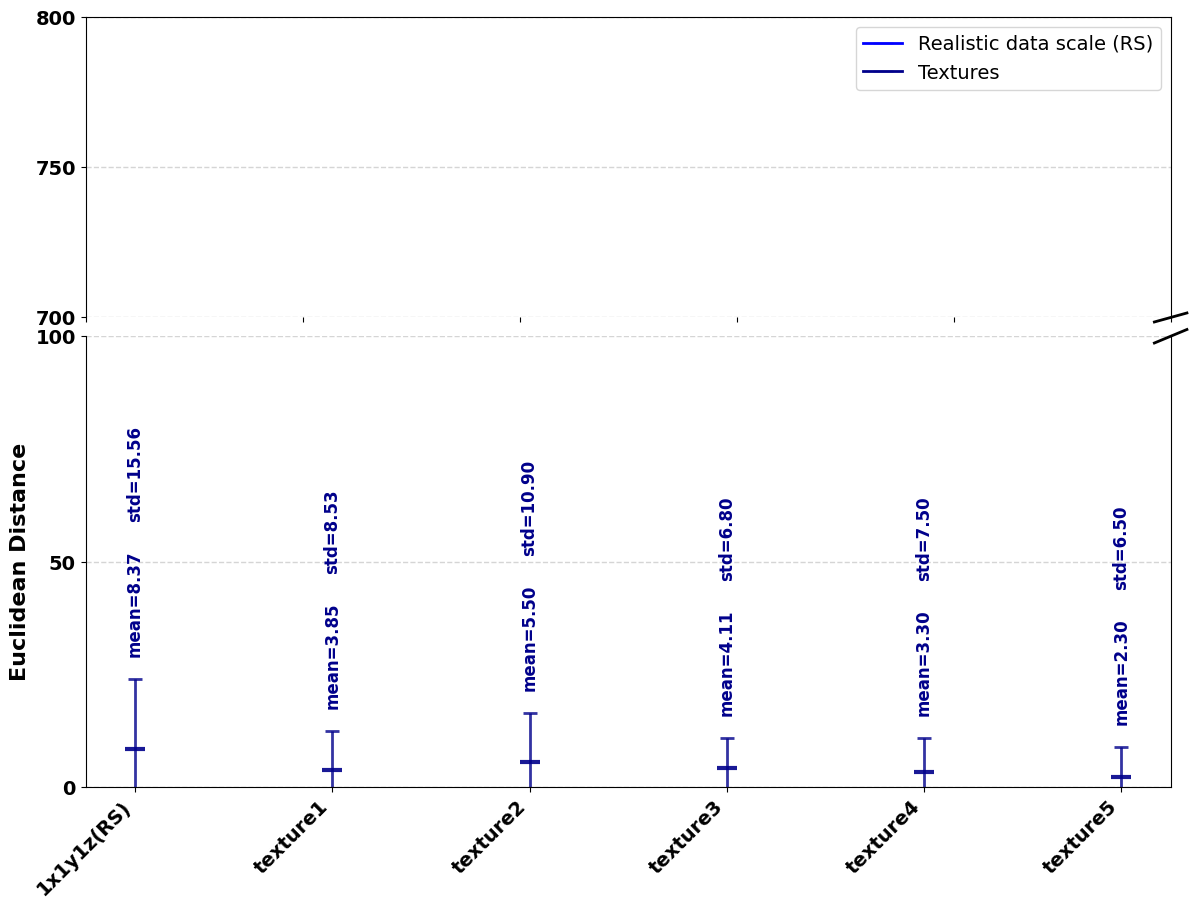


DATA SUMMARY - TEXTURES
   Type       Name  Mean Euclidean Distance  Std Euclidean Distance
  Scale 1x1y1z(RS)                     8.37                   15.56
Texture   texture1                     3.85                    8.53
Texture   texture2                     5.50                   10.90
Texture   texture3                     4.11                    6.80
Texture   texture4                     3.30                    7.50
Texture   texture5                     2.30                    6.50


In [3]:
"""
Inter-Rater Error Bar Chart with Broken Y-Axis - TEXTURES ONLY
Creates error bar chart with broken y-axis for Textures only
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'
DISTANCE_MULTIPLIER = 1  # Multiply Y-axis by 64

# Data from the results
data = {
    'Type': ['Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale',
             'Texture', 'Texture', 'Texture', 'Texture', 'Texture'],
    'Name': ['1x1y1z(RS)', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x2y1z', '3x1y2z', '3x2y2z',
             'texture1', 'texture2', 'texture3', 'texture4', 'texture5'],
    
    'Mean Euclidean Distance': [8.37, 8.82, 9.17, 1.35, 30.5, 24.5, 12.7, 34.8, 9.5, 12, 3.85, 5.5, 4.11, 3.3, 2.3],
    'Std Euclidean Distance': [15.56, 20.70, 15.6, 4.7, 51.49, 39.9, 41.6, 89.1, 19.0, 21, 8.53, 10.9, 6.8, 7.5, 6.5]
}

df = pd.DataFrame(data)

# Get 1x1y1z(GT) from scales and textures
scale_data = df[df['Type'] == 'Scale']
texture_data = df[df['Type'] == 'Texture']

# Find 1x1y1z(GT) from scales
gt_row = scale_data[scale_data['Name'] == '1x1y1z(RS)'].copy()

# Combine: 1x1y1z(GT) first, then textures
if len(gt_row) > 0:
    texture_data = pd.concat([gt_row, texture_data], ignore_index=True)

# Create figure with broken y-axis (crop 300-600)
# Note: High values (600-800) at top, low values (0-300) at bottom
# Top part is 2/3 of bottom part height, same scale step
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.05)  # Top is 2/3 of bottom

# Top subplot (600 to 800) - displayed at top (high values)
ax2 = fig.add_subplot(gs[0, 0])
# Bottom subplot (0 to 300) - displayed at bottom (low values)
ax1 = fig.add_subplot(gs[1, 0])

# Y-axis break parameters
Y_BOTTOM_MAX = 100
Y_TOP_MIN = 700
Y_TOP_MAX = 800

# Calculate x positions for textures only
x_pos_texture = np.arange(len(texture_data))

# Plot textures on both axes
texture_text_positions_bottom = []
texture_text_positions_top = []
if len(texture_data) > 0:
    texture_names = texture_data['Name'].tolist()
    texture_means = (texture_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    texture_stds = (texture_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    # Color: red for 1x1y1z(GT), darkblue for textures
    texture_colors = ['darkblue' if name == '1x1y1z(RS)' else 'darkblue' for name in texture_names]
    
    for i, (mean, std, color, name) in enumerate(zip(texture_means, texture_stds, texture_colors, texture_names)):
        # Plot on bottom if value <= 300
        if mean <= Y_BOTTOM_MAX:
            ax1.errorbar(x_pos_texture[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax1.plot(x_pos_texture[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            texture_text_positions_bottom.append((x_pos_texture[i], mean, std, color, mean))
        # Plot on top if value >= 600
        elif mean >= Y_TOP_MIN:
            ax2.errorbar(x_pos_texture[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax2.plot(x_pos_texture[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            texture_text_positions_top.append((x_pos_texture[i], mean, std, color, mean))

# Use texture names and positions only
all_names = texture_data['Name'].tolist()
all_x_pos = list(x_pos_texture)

# Configure top subplot (600-800) - displayed at top (high values)
ax2.set_xticks(all_x_pos)
ax2.set_xticklabels([])  # Hide x labels on top subplot
ax2.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax2.set_ylim(bottom=Y_TOP_MIN, top=Y_TOP_MAX)
ax2.spines['bottom'].set_visible(False)  # Hide bottom spine (broken axis)

# Set same scale step for both subplots (50 units per step)
tick_step = 50
ax2.set_yticks(np.arange(Y_TOP_MIN, Y_TOP_MAX + tick_step, tick_step))

# Configure bottom subplot (0-300) - displayed at bottom (low values)
ax1.set_ylabel(f'Euclidean Distance', fontsize=16, fontweight='bold')
ax1.set_xticks(all_x_pos)
ax1.set_xticklabels(all_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax1.set_ylim(bottom=0, top=Y_BOTTOM_MAX)
ax1.spines['top'].set_visible(False)  # Hide top spine (broken axis)

# Set same scale step for both subplots (50 units per step)
ax1.set_yticks(np.arange(0, Y_BOTTOM_MAX + tick_step, tick_step))

# Add broken axis indicators (diagonal lines)
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=2)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  # Bottom-right diagonal (at bottom of top subplot)

kwargs.update(transform=ax1.transAxes)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # Top-right diagonal (at top of bottom subplot)

# Add mean and std text vertically on top of each bar for TEXTURES (bottom subplot - 0-300, low values)
for x_pos, mean, std, color, _ in texture_text_positions_bottom:
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean + std + offset
    text_spacing = Y_BOTTOM_MAX * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax1.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax1.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add mean and std text vertically on top of each bar for TEXTURES (top subplot - 600-800, high values)
for x_pos, mean, std, color, _ in texture_text_positions_top:
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean + std + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax2.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax2.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add legend (on top subplot - ax2, high values)
legend_elements = [
    plt.Line2D([0], [0], color='blue', linewidth=2, marker='_', markersize=15, label='Realistic data scale (RS)'),
    plt.Line2D([0], [0], color='darkblue', linewidth=2, marker='_', markersize=15, label='Textures')
]
ax2.legend(handles=legend_elements, fontsize=14, loc='upper right')
plt.setp(ax1.get_yticklabels(), fontsize=14, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_error_bar_broken_axis_TEXTURES.png')
plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
print(f"✓ Inter-rater error bar chart with broken axis (TEXTURES) saved to: {interrater_path}")
plt.show()

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY - TEXTURES")
print("="*70)
print(texture_data.to_string(index=False))
print("="*70)


C:\Users\hosse\AppData\Local\Temp\ipykernel_41876\871558628.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


: 

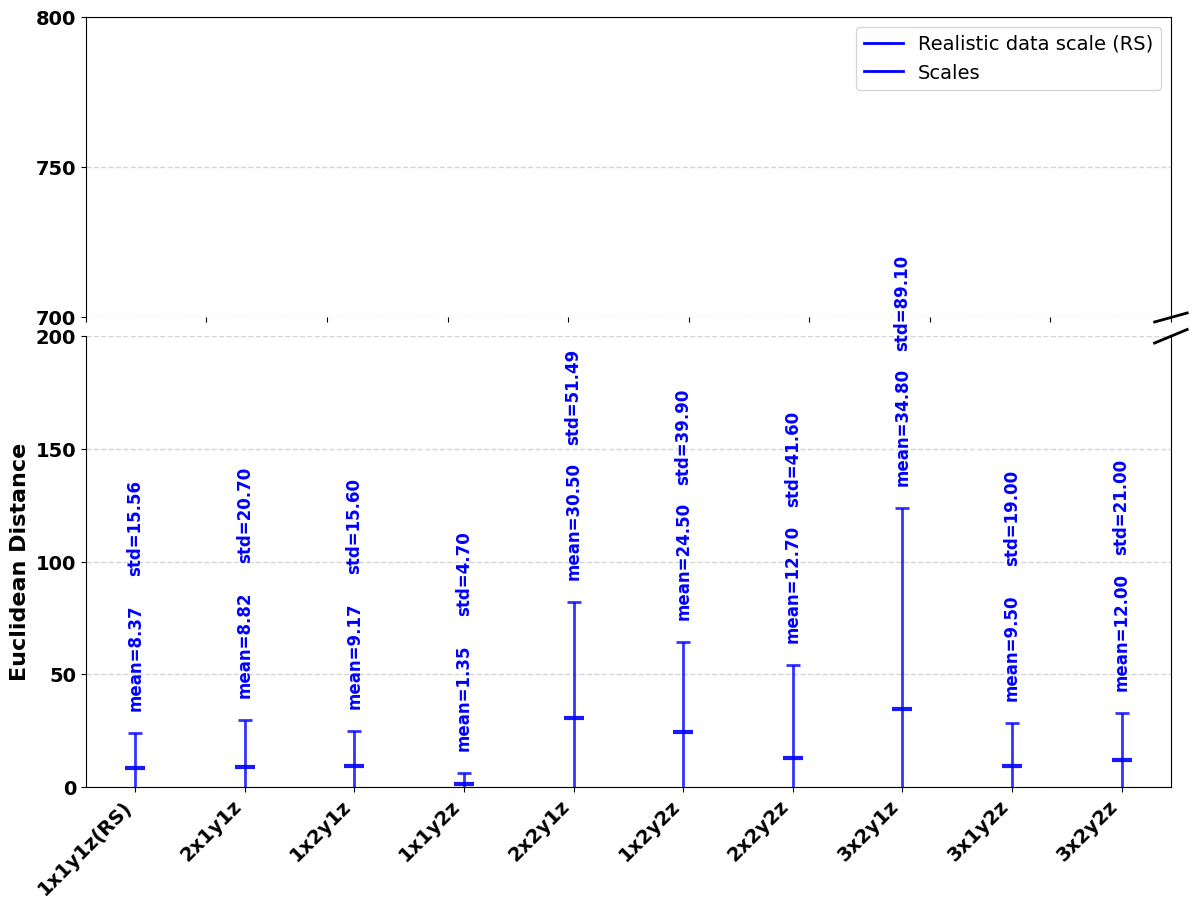

In [6]:
"""
Inter-Rater Error Bar Chart with Broken Y-Axis - SCALES ONLY
Creates error bar chart with broken y-axis for Scales only
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale_text_synthetic'
DISTANCE_MULTIPLIER = 1  # Multiply Y-axis by 64

# Original dimensions
ORIGINAL_X = 681
ORIGINAL_Y = 344
ORIGINAL_Z = 12

# Base maximum for 1x1y1z
BASE_MAX = 761

# Function to parse scale name and extract scale factors
def parse_scale_name(name):
    """Extract scale factors from name like '2x1y1z' or '1x1y1z(RS)'"""
    import re
    # Remove (RS) or (GT) suffix if present
    name_clean = re.sub(r'\([^)]+\)', '', name).strip()
    # Extract numbers before x, y, z
    match = re.match(r'(\d+)x(\d+)y(\d+)z', name_clean)
    if match:
        return int(match.group(1)), int(match.group(2)), int(match.group(3))
    return 1, 1, 1  # Default to 1x1y1z if parsing fails

# Function to calculate maximum Y for a given scale
def calculate_max_y(scale_x, scale_y, scale_z):
    """Calculate maximum Y based on scale factors"""
    # Calculate Euclidean distance for scaled dimensions
    scaled_dist = np.sqrt((scale_x * ORIGINAL_X)**2 + (scale_y * ORIGINAL_Y)**2 + (scale_z * ORIGINAL_Z)**2)
    # Calculate Euclidean distance for base (1x1y1z)
    base_dist = np.sqrt((1 * ORIGINAL_X)**2 + (1 * ORIGINAL_Y)**2 + (1 * ORIGINAL_Z)**2)
    # Scale the maximum proportionally
    max_y = BASE_MAX * (scaled_dist / base_dist)
    return max_y

# Data from the results
data = {
    'Type': ['Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale', 'Scale',
             'Texture', 'Texture', 'Texture', 'Texture', 'Texture'],
    'Name': ['1x1y1z(RS)', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x2y1z', '3x1y2z', '3x2y2z',
             'texture1', 'texture2', 'texture3', 'texture4', 'texture5'],
    
    'Mean Euclidean Distance': [8.37, 8.82, 9.17, 1.35, 30.5, 24.5, 12.7, 34.8, 9.5, 12, 3.85, 5.5, 4.11, 3.3, 2.3],
    'Std Euclidean Distance': [15.56, 20.70, 15.6, 4.7, 51.49, 39.9, 41.6, 89.1, 19.0, 21, 8.53, 10.9, 6.8, 7.5, 6.5]
}

df = pd.DataFrame(data)

# Separate scales and textures
scale_data = df[df['Type'] == 'Scale'].copy()

# Calculate maximum Y for each scale
scale_data['Max_Y'] = scale_data['Name'].apply(
    lambda name: calculate_max_y(*parse_scale_name(name))
)

# Create figure with broken y-axis (crop 300-600)
# Note: High values (600-800) at top, low values (0-300) at bottom
# Top part is 2/3 of bottom part height, same scale step
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.05)  # Top is 2/3 of bottom

# Top subplot (600 to 800) - displayed at top (high values)
ax2 = fig.add_subplot(gs[0, 0])
# Bottom subplot (0 to 300) - displayed at bottom (low values)
ax1 = fig.add_subplot(gs[1, 0])

# Y-axis break parameters
Y_BOTTOM_MAX = 200
Y_TOP_MIN = 700
Y_TOP_MAX = 800

# Calculate x positions for scales only
x_pos_scale = np.arange(len(scale_data))

# Plot scales on both axes
scale_text_positions_bottom = []
scale_text_positions_top = []
if len(scale_data) > 0:
    scale_names = scale_data['Name'].tolist()
    scale_means = (scale_data['Mean Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_stds = (scale_data['Std Euclidean Distance'] * DISTANCE_MULTIPLIER).tolist()
    scale_colors = ['blue' if name == '1x1y1z(RS)' else 'blue' for name in scale_names]
    
    for i, (mean, std, color, name) in enumerate(zip(scale_means, scale_stds, scale_colors, scale_names)):
        # Plot on bottom if value <= 300
        if mean <= Y_BOTTOM_MAX:
            ax1.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax1.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_bottom.append((x_pos_scale[i], mean, std, color, mean))
        # Plot on top if value >= 600
        elif mean >= Y_TOP_MIN:
            ax2.errorbar(x_pos_scale[i], mean, yerr=std, fmt='none', color=color, capsize=5, capthick=2, linewidth=2, alpha=0.8)
            ax2.plot(x_pos_scale[i], mean, marker='_', color=color, markersize=15, markeredgewidth=3, alpha=0.9)
            scale_text_positions_top.append((x_pos_scale[i], mean, std, color, mean))

# Use scale names and positions only
all_names = scale_data['Name'].tolist()
all_x_pos = list(x_pos_scale)

# Configure top subplot (600-800) - displayed at top (high values)
ax2.set_xticks(all_x_pos)
ax2.set_xticklabels([])  # Hide x labels on top subplot
ax2.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax2.set_ylim(bottom=Y_TOP_MIN, top=Y_TOP_MAX)
ax2.spines['bottom'].set_visible(False)  # Hide bottom spine (broken axis)

# Set same scale step for both subplots (50 units per step)
tick_step = 50
ax2.set_yticks(np.arange(Y_TOP_MIN, Y_TOP_MAX + tick_step, tick_step))

# Configure bottom subplot (0-300) - displayed at bottom (low values)
ax1.set_ylabel(f'Euclidean Distance', fontsize=16, fontweight='bold')
ax1.set_xticks(all_x_pos)
ax1.set_xticklabels(all_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax1.set_ylim(bottom=0, top=Y_BOTTOM_MAX)
ax1.spines['top'].set_visible(False)  # Hide top spine (broken axis)

# Set same scale step for both subplots (50 units per step)
ax1.set_yticks(np.arange(0, Y_BOTTOM_MAX + tick_step, tick_step))

# Add broken axis indicators (diagonal lines)
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=2)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  # Bottom-right diagonal (at bottom of top subplot)

kwargs.update(transform=ax1.transAxes)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # Top-right diagonal (at top of bottom subplot)

# Add mean and std text vertically on top of each bar for SCALES (bottom subplot - 0-300, low values)
for i, (x_pos, mean, std, color, _) in enumerate(scale_text_positions_bottom):
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean + std + offset
    text_spacing = Y_BOTTOM_MAX * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax1.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax1.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add mean and std text vertically on top of each bar for SCALES (top subplot - 600-800, high values)
for i, (x_pos, mean, std, color, _) in enumerate(scale_text_positions_top):
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean + std + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.30  # Distance between mean and std (relative to range) - increased more
    # Place mean and std vertically, one after another with proper spacing
    ax2.text(x_pos, text_y_base, f'mean={mean:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)
    ax2.text(x_pos, text_y_base + text_spacing, f'std={std:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color, rotation=90)

# Add legend (on top subplot - ax2, high values)
legend_elements = [
    plt.Line2D([0], [0], color='blue', linewidth=2, marker='_', markersize=15, label='Realistic data scale (RS)'),
    plt.Line2D([0], [0], color='blue', linewidth=2, marker='_', markersize=15, label='Scales')
]
ax2.legend(handles=legend_elements, fontsize=14, loc='upper right')
plt.setp(ax1.get_yticklabels(), fontsize=14, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
interrater_path = os.path.join(BASE_DIR, 'inter_rater_euclidean_distance_error_bar_broken_axis_SCALES.png')
plt.savefig(interrater_path, dpi=300, bbox_inches='tight')
print(f"✓ Inter-rater error bar chart with broken axis (SCALES) saved to: {interrater_path}")
plt.show()

# Display data summary
print("\n" + "="*70)
print("DATA SUMMARY - SCALES")
print("="*70)
print(scale_data.to_string(index=False))
print("="*70)


C:\Users\hosse\AppData\Local\Temp\ipykernel_41876\252144719.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Min, Mean, Std statistics chart with broken axis saved to: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale\min_mean_std_statistics_broken_axis.png


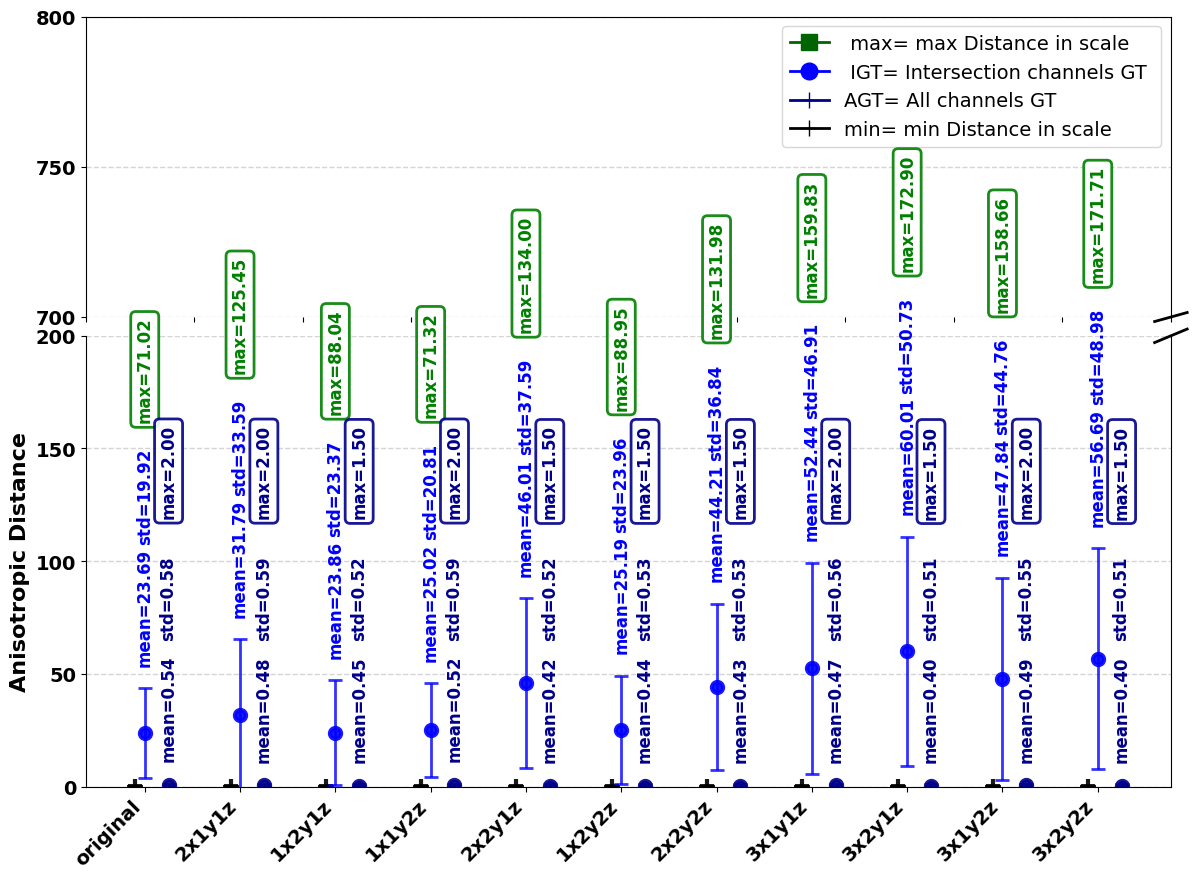


SUMMARY TABLE - IGT and AGT Statistics by Scale
   Scale   Config  Textures  GT Mean  GT Median  GT Std  AGT Mean  AGT Median  AGT Std
original 1x,1y,1z         5  23.6905    19.3300 19.9245    0.5387         0.4   0.5840
  2x1y1z 2x,1y,1z         5  31.7861    17.6187 33.5934    0.4837         0.2   0.5911
  1x2y1z 1x,2y,1z         5  23.8581    15.0216 23.3678    0.4528         0.2   0.5212
  1x1y2z 1x,1y,2z         5  25.0233    23.3615 20.8056    0.5207         0.4   0.5936
  2x2y1z 2x,2y,1z         5  46.0084    39.1805 37.5860    0.4169         0.2   0.5235
  1x2y2z 1x,2y,2z         5  25.1885    18.0791 23.9605    0.4443         0.2   0.5271
  2x2y2z 2x,2y,2z         5  44.2100    38.9972 36.8417    0.4284         0.2   0.5346
  3x1y1z 3x,1y,1z         5  52.4382    45.4047 46.9050    0.4662         0.2   0.5574
  3x2y1z 3x,2y,1z         5  60.0139    57.1467 50.7299    0.4032         0.2   0.5112
  3x1y2z 3x,1y,2z         5  47.8429    37.0348 44.7645    0.4852         0.2   0

In [44]:
"""
Min, Mean, Std Statistics Chart with Broken Y-Axis - SCALES
Creates error bar chart with broken y-axis showing Min, Mean, and Std for each scale
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\Scale'

# Data from the summary table
summary_data = {
    'Scale': ['original', '2x1y1z', '1x2y1z', '1x1y2z', '2x2y1z', '1x2y2z', '2x2y2z', '3x1y1z', '3x2y1z', '3x1y2z', '3x2y2z'],
    'Config': ['1x,1y,1z', '2x,1y,1z', '1x,2y,1z', '1x,1y,2z', '2x,2y,1z', '1x,2y,2z', '2x,2y,2z', '3x,1y,1z', '3x,2y,1z', '3x,1y,2z', '3x,2y,2z'],
    'Textures': [5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
    # IGT (GT) data
    'IGT_Mean': [23.6905, 31.7861, 23.8581, 25.0233, 46.0084, 25.1885, 44.2100, 52.4382, 60.0139, 47.8429, 56.6905],
    'IGT_Median': [19.3300, 17.6187, 15.0216, 23.3615, 39.1805, 18.0791, 38.9972, 45.4047, 57.1467, 37.0348, 50.7384],
    'IGT_Std': [19.9245, 33.5934, 23.3678, 20.8056, 37.5860, 23.9605, 36.8417, 46.9050, 50.7299, 44.7645, 48.9797],
    'IGT_Min': [0.23, 0.2800, 0.0000, 0.2000, 0.4800, 0.2000, 0.2000, 0.0000, 0.2800, 0.2000, 0.2000],
    'IGT_Max': [71.0233, 125.4487, 88.0353, 71.3194, 133.9954, 88.9463, 131.9847, 159.8317, 172.9006, 158.6630, 171.7110],
    # AGT data
    'AGT_Mean': [0.5387, 0.4837, 0.4528, 0.5207, 0.4169, 0.4443, 0.4284, 0.4662, 0.4032, 0.4852, 0.3992],
    'AGT_Median': [0.4000, 0.2000, 0.2000, 0.4000, 0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.2000],
    'AGT_Std': [0.5840, 0.5911, 0.5212, 0.5936, 0.5235, 0.5271, 0.5346, 0.5574, 0.5112, 0.5462, 0.5106],
    'AGT_Min': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'AGT_Max': [2.0, 2.0, 1.5, 2.0, 1.5, 1.5, 1.5, 2.0, 1.5, 2.0, 1.5]
}

df_summary = pd.DataFrame(summary_data)

# Create figure with broken y-axis (same as inter-rater chart)
# Top part is 2/3 of bottom part height, same scale step
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, height_ratios=[2, 3], hspace=0.05)  # Top is 2/3 of bottom

# Top subplot (600 to 800) - displayed at top (high values)
ax2 = fig.add_subplot(gs[0, 0])
# Bottom subplot (0 to 300) - displayed at bottom (low values)
ax1 = fig.add_subplot(gs[1, 0])

# Y-axis break parameters (same as inter-rater chart)
Y_BOTTOM_MAX = 200
Y_TOP_MIN = 700
Y_TOP_MAX = 800

# Calculate x positions
x_pos = np.arange(len(df_summary))

# Colors
color_igt = 'blue'  # Blue for IGT (mean, std)
color_igt_max = 'green'  # Green for IGT max
color_agt = 'darkblue'   # Dark blue for AGT (mean, std, max)
color_min = 'black'  # Black color for min

# Store positions for text labels (Mean, Std, Max in vertical line)
text_positions_bottom = []  # (x_pos, mean, std, max, color_mean, color_max, is_igt)
text_positions_top = []

# Spacing between IGT and AGT bars
bar_spacing = 0.25  # Reduced spacing between IGT and AGT for closer bars
# Small offset for Std to align vertically with Mean (slight x difference)
std_offset = 0.08  # Small x offset for Std to be vertically aligned with Mean

for i in range(len(df_summary)):
    # IGT values (GT = IGT)
    igt_mean = df_summary['IGT_Mean'].iloc[i]
    igt_std = df_summary['IGT_Std'].iloc[i]
    igt_min = df_summary['IGT_Min'].iloc[i]
    igt_max = df_summary['IGT_Max'].iloc[i]
    
    # AGT values
    agt_mean = df_summary['AGT_Mean'].iloc[i]
    agt_std = df_summary['AGT_Std'].iloc[i]
    agt_min = df_summary['AGT_Min'].iloc[i]
    agt_max = df_summary['AGT_Max'].iloc[i]
    
    # Plot IGT Min (always at y=0) - black with '+' marker
    ax1.errorbar(x_pos[i] - 0.1, 0, yerr=0, fmt='none', color=color_min, capsize=5, capthick=4, linewidth=4, alpha=0.8)
    ax1.plot(x_pos[i] - 0.1, 0, marker='+', color=color_min, markersize=12, markeredgewidth=3, alpha=0.9)
    
    # Plot IGT Mean
    if igt_mean <= Y_BOTTOM_MAX:
        ax1.errorbar(x_pos[i], igt_mean, yerr=igt_std, fmt='none', color=color_igt, capsize=5, capthick=2, linewidth=2, alpha=0.8)
        ax1.plot(x_pos[i], igt_mean, marker='o', color=color_igt, markersize=8, markeredgewidth=3, alpha=0.9)
        text_positions_bottom.append((x_pos[i], igt_mean, igt_std, igt_max, color_igt, color_igt_max, True))
    elif igt_mean >= Y_TOP_MIN:
        ax2.errorbar(x_pos[i], igt_mean, yerr=igt_std, fmt='none', color=color_igt, capsize=5, capthick=2, linewidth=2, alpha=0.8)
        ax2.plot(x_pos[i], igt_mean, marker='o', color=color_igt, markersize=8, markeredgewidth=3, alpha=0.9)
        text_positions_top.append((x_pos[i], igt_mean, igt_std, igt_max, color_igt, color_igt_max, True))
    
    # IGT Std - no marker, only text label (will be shown in vertical line above bar)
    
    # Plot AGT Mean (beside IGT with spacing)
    if agt_mean <= Y_BOTTOM_MAX:
        ax1.errorbar(x_pos[i] + bar_spacing, agt_mean, yerr=agt_std, fmt='none', color=color_agt, capsize=5, capthick=2, linewidth=2, alpha=0.8)
        ax1.plot(x_pos[i] + bar_spacing, agt_mean, marker='o', color=color_agt, markersize=8, markeredgewidth=3, alpha=0.9)
        text_positions_bottom.append((x_pos[i] + bar_spacing, agt_mean, agt_std, agt_max, color_agt, color_agt, False))
    elif agt_mean >= Y_TOP_MIN:
        ax2.errorbar(x_pos[i] + bar_spacing, agt_mean, yerr=agt_std, fmt='none', color=color_agt, capsize=5, capthick=2, linewidth=2, alpha=0.8)
        ax2.plot(x_pos[i] + bar_spacing, agt_mean, marker='o', color=color_agt, markersize=8, markeredgewidth=3, alpha=0.9)
        text_positions_top.append((x_pos[i] + bar_spacing, agt_mean, agt_std, agt_max, color_agt, color_agt, False))
    
    # AGT Std - no marker, only text label (will be shown in vertical line above bar)

# Configure top subplot (600-800) - displayed at top (high values)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([])  # Hide x labels on top subplot
ax2.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax2.set_ylim(bottom=Y_TOP_MIN, top=Y_TOP_MAX)
ax2.spines['bottom'].set_visible(False)  # Hide bottom spine (broken axis)

# Set same scale step for both subplots (50 units per step)
tick_step = 50
ax2.set_yticks(np.arange(Y_TOP_MIN, Y_TOP_MAX + tick_step, tick_step))

# Configure bottom subplot (0-300) - displayed at bottom (low values)
ax1.set_ylabel(f'Anisotropic Distance', fontsize=16, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_summary['Scale'], rotation=45, ha='right', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.530, linestyle='--', linewidth=1)
ax1.set_ylim(bottom=0, top=Y_BOTTOM_MAX)
ax1.spines['top'].set_visible(False)  # Hide top spine (broken axis)

# Set same scale step for both subplots (50 units per step)
ax1.set_yticks(np.arange(0, Y_BOTTOM_MAX + tick_step, tick_step))

# Add broken axis indicators (diagonal lines)
d = 0.015  # Size of diagonal lines
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=2)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)  # Bottom-right diagonal (at bottom of top subplot)

kwargs.update(transform=ax1.transAxes)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)  # Top-right diagonal (at top of bottom subplot)

# Add text labels in vertical line above each bar (Mean, Std, Max) - bottom subplot
# Order: mean (bottom), std (middle), max (top)
for x_pos_val, mean_val, std_val, max_val, color_mean, color_max, is_igt in text_positions_bottom:
    offset = Y_BOTTOM_MAX * 0.05
    text_y_base = mean_val + std_val + offset
    text_spacing = Y_BOTTOM_MAX * 0.27  # Reduced spacing between labels (mean, std, max)
    
    # Mean label (bottom)
    ax1.text(x_pos_val, text_y_base, f'mean={mean_val:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color_mean, rotation=90)
    
    # Std label (middle, after mean)
    std_text_y = text_y_base + text_spacing
    ax1.text(x_pos_val, std_text_y, f'std={std_val:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color_mean, rotation=90)
    
    # Max label (top)
    max_text_y = std_text_y + text_spacing
    ax1.text(x_pos_val, max_text_y, f'max={max_val:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color_max, rotation=90,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color_max, linewidth=2))

# Add text labels in vertical line above each bar (Mean, Std, Max) - top subplot
# Order: mean (bottom), std (middle), max (top)
for x_pos_val, mean_val, std_val, max_val, color_mean, color_max, is_igt in text_positions_top:
    offset = (Y_TOP_MAX - Y_TOP_MIN) * 0.05
    text_y_base = mean_val + std_val + offset
    text_spacing = (Y_TOP_MAX - Y_TOP_MIN) * 0.27  # Reduced spacing between labels (mean, std, max)
    
    # Mean label (bottom)
    ax2.text(x_pos_val, text_y_base, f'mean={mean_val:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color_mean, rotation=90)
    
    # Std label (middle, after mean)
    std_text_y = text_y_base + text_spacing
    ax2.text(x_pos_val, std_text_y, f'std={std_val:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color_mean, rotation=90)
    
    # Max label (top)
    max_text_y = std_text_y + text_spacing
    ax2.text(x_pos_val, max_text_y, f'max={max_val:.2f}', 
           ha='center', va='bottom', fontsize=12, fontweight='heavy', color=color_max, rotation=90,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color_max, linewidth=2))

# Add legend (on top subplot - ax2, high values)
legend_elements = [
    plt.Line2D([0], [0], color='darkgreen', linewidth=2, marker='s', markersize=12, label=' max= max Distance in scale'),
    plt.Line2D([0], [0], color='blue', linewidth=2, marker='o', markersize=12, label=' IGT= Intersection channels GT '),
    plt.Line2D([0], [0], color='darkblue', linewidth=2, marker='+', markersize=12, label='AGT= All channels GT  '),
    plt.Line2D([0], [0], color='black', linewidth=2, marker='+', markersize=12, label='min= min Distance in scale  ')


]
ax2.legend(handles=legend_elements, fontsize=14, loc='upper right')
plt.setp(ax1.get_yticklabels(), fontsize=14, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=14, fontweight='bold')

plt.tight_layout()

# Save plot
output_path = os.path.join(BASE_DIR, 'min_mean_std_statistics_broken_axis.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Min, Mean, Std statistics chart with broken axis saved to: {output_path}")
plt.show()

# Display data summary
print("\n" + "="*180)
print("SUMMARY TABLE - IGT and AGT Statistics by Scale")
print("="*180)
display_cols = ['Scale', 'Config', 'Textures', 
                'IGT_Mean', 'IGT_Median', 'IGT_Std', 
                'AGT_Mean', 'AGT_Median', 'AGT_Std']
display_df = df_summary[display_cols].copy()
display_df.columns = ['Scale', 'Config', 'Textures', 
                      'GT Mean', 'GT Median', 'GT Std',
                      'AGT Mean', 'AGT Median', 'AGT Std']
print(display_df.to_string(index=False))
print("="*180)